<a href="https://colab.research.google.com/github/kdona/erdos-2026-deep-learning-emg-pose/blob/main/regression_baseline_DRAFT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Baseline modeling: Regression

## Purpose
Prepares data pipeline for scikit-learn regression baseline

1. Set up paths for **local vs Colab**
2. Filter metadata w/ strict training hygiene (`held_out_user == False`) for the pilot 10-user subset
3. Build `WindowedEmgDataset` w/ our `UserChannelZScoreNormalize` transform
4. Load 1-second windows & flatten sEMG tensors from `(Batch, Channels, Time)` to `(Batch, Channels * Time)`
5. Accumulates `X_train`, `y_train`, `X_val`, and `y_val` arrays

TBD:
- Model not trained yet
- Metrics not evaluated yet

In [1]:
# -----------------------------
# 1) Environment Toggle and Paths
# -----------------------------
RUN_IN_COLAB = True # Set this to True in Colab, False on local machine.

if RUN_IN_COLAB:
  from google.colab import drive
  drive.mount("/content/drive", force_remount=True)

  # need to install hydra-core in order to use utils files from the emg2pose directory
  %pip install hydra-core

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 4.1 MB/s eta 0:00:00


In [2]:
if RUN_IN_COLAB:
  !mkdir -p ~/.kaggle
  !cp "/content/drive/MyDrive/Erdos-deep-learning/content/kaggle.json" ~/.kaggle/kaggle.json
  !chmod 600 ~/.kaggle/kaggle.json

Import the data files from the Kaggle database so we can work with them!

In [3]:
 %%time
if RUN_IN_COLAB:
  # Download latest version of dataset,  takes at least 20 minutes unfortunatley
  import kagglehub
  path = kagglehub.dataset_download("serotorianoparelphd/pilot-files-10users-1584")
  print("Path to dataset files:", path)

Using Colab cache for faster access to the 'pilot-files-10users-1584' dataset.
Path to dataset files: /kaggle/input/pilot-files-10users-1584
CPU times: user 347 ms, sys: 43.3 ms, total: 390 ms
Wall time: 3.44 s


In [4]:
from pathlib import Path
if RUN_IN_COLAB:
    # Adjust these paths based on your Colab mount layout.
    PROJECT_ROOT = Path("/content/drive/MyDrive/Erdos-deep-learning/content")
    DATASET_ROOT = Path(path) # path obtained from kagglehub.dataset_download
    DATA_LOCATION = DATASET_ROOT  # This folder should contain many .hdf5 files.
else:
    PROJECT_ROOT = Path('/Volumes/emg2pose/emg2pose')
    DATASET_ROOT = Path('/Volumes/emg2pose/dataset')
    DATA_LOCATION = DATASET_ROOT / 'emg2pose_data'  # This folder should contain many .hdf5 files.



# We generated this with the offline stats script.
SCALER_PATH = PROJECT_ROOT / 'data' / 'user_scalers.pkl'

# Metadata usually exists in one of these two places.
POSSIBLE_METADATA_PATHS = [
    DATA_LOCATION / 'metadata.csv',
    DATASET_ROOT / 'metadata.csv',
]

METADATA_PATH = None
for one_candidate_path in POSSIBLE_METADATA_PATHS:
    if one_candidate_path.exists():
        METADATA_PATH = one_candidate_path
        break

if METADATA_PATH is None: raise FileNotFoundError('Could not locate metadata.csv in expected locations.')

if not SCALER_PATH.exists(): raise FileNotFoundError(f'Missing scaler file: {SCALER_PATH}')

print('PROJECT_ROOT =', PROJECT_ROOT)
print('DATA_LOCATION =', DATA_LOCATION)
print('METADATA_PATH =', METADATA_PATH)
print('SCALER_PATH  =', SCALER_PATH)

PROJECT_ROOT = /content/drive/MyDrive/Erdos-deep-learning/content
DATA_LOCATION = /kaggle/input/pilot-files-10users-1584
METADATA_PATH = /kaggle/input/pilot-files-10users-1584/metadata.csv
SCALER_PATH  = /content/drive/MyDrive/Erdos-deep-learning/content/data/user_scalers.pkl


In [5]:
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader, ConcatDataset
import sys
sys.path.insert(0, str(PROJECT_ROOT))

from emg2pose.data import WindowedEmgDataset
from emg2pose.transforms import Compose, ExtractToTensor, UserChannelZScoreNormalize


# parent of the emg2pose/ folder
sys.path.insert(0, str(PROJECT_ROOT))

print("sys.path[0] =", sys.path[0])
print("emg2pose dir exists:", (PROJECT_ROOT / "emg2pose").exists())

sys.path[0] = /content/drive/MyDrive/Erdos-deep-learning/content
emg2pose dir exists: True


## Split policy

We only use our pilot 10-user subset in this notebook, then enforce:
- **Training subset:** `held_out_user == False` (7 users)
- **Validation subset:** `held_out_user == True` and `split == 'val'` (2 users)

This avoids leakage and also gives us a validation pass where dynamic fallback should trigger.


In [6]:
# -----------------------------
# 2) Read Metadata and Build Strict Train/Val File Lists
# -----------------------------

metadata_dataframe = pd.read_csv(METADATA_PATH)

# Pilot subset users
pilot_user_ids = [
    '8e69533c16',
    '3976352430',
    '2942949786',
    '1896997952',
    '0625995630',
    '2668760727',
    '3589743749',
    '2251681168',
    '2af4aec870',
    '7e08fa55fd',
]

pilot_metadata = metadata_dataframe[metadata_dataframe['user'].isin(pilot_user_ids)].copy()

# Train rows: strict no-leakage filter
train_rows = pilot_metadata[pilot_metadata['held_out_user'] == False].copy()
train_rows = train_rows[train_rows['split'] == 'train'].copy()

# Validation rows for fallback test
validation_rows = pilot_metadata[pilot_metadata['held_out_user'] == True].copy()
validation_rows = validation_rows[validation_rows['split'] == 'val'].copy()

train_user_ids = sorted(train_rows['user'].unique().tolist())
validation_user_ids = sorted(validation_rows['user'].unique().tolist())

print('Train users (expected 7):', train_user_ids)
print('Validation users (expected 2):', validation_user_ids)

if len(train_user_ids) != 7: raise ValueError(f'Expected 7 train users in pilot subset, found {len(train_user_ids)}')
if len(validation_user_ids) == 0: raise ValueError('Validation user list is empty. Cannot test fallback path.')

# Use filename column to build exact HDF5 paths
# filename values do NOT include .hdf5 suffix
train_filenames = sorted(train_rows['filename'].unique().tolist())
validation_filenames = sorted(validation_rows['filename'].unique().tolist())

train_hdf5_paths = []
for one_filename in train_filenames:
    one_path = DATA_LOCATION / f'{one_filename}.hdf5'
    if one_path.exists():
        train_hdf5_paths.append(one_path)

validation_hdf5_paths = []
for one_filename in validation_filenames:
    one_path = DATA_LOCATION / f'{one_filename}.hdf5'
    if one_path.exists():
        validation_hdf5_paths.append(one_path)

print('Usable train files:', len(train_hdf5_paths))
print('Usable validation files:', len(validation_hdf5_paths))

if len(train_hdf5_paths) == 0: raise ValueError('No train HDF5 files found for the selected pilot split.')
if len(validation_hdf5_paths) == 0:  raise ValueError('No validation HDF5 files found for the selected pilot split.')


Train users (expected 7): ['0625995630', '1896997952', '2668760727', '2942949786', '3589743749', '3976352430', '8e69533c16']
Validation users (expected 2): ['2251681168', '2af4aec870']
Usable train files: 953
Usable validation files: 308


## Transform and Dataset Construction

We apply the transform pipeline:
1. `ExtractToTensor(field='emg')`
2. `UserChannelZScoreNormalize(user_stats_path=...)`

Important behavior:
- Train users are in `user_scalers.pkl` and use precomputed per-user/channel stats.
- Validation held-out users are not in that file and should use dynamic fallback normalization.


In [7]:
# -----------------------------
# 3) Build Transform and Datasets
# -----------------------------

normalization_transform = UserChannelZScoreNormalize(
    user_stats_path=str(SCALER_PATH)
)

transform_pipeline = Compose([
    ExtractToTensor(field='emg'),
    normalization_transform,
])

# 1 second windows at 2kHz = 2000 timesteps.
WINDOW_LENGTH = 2000
WINDOW_STRIDE = 2000

train_session_datasets = []
for one_hdf5_path in train_hdf5_paths:
    one_dataset = WindowedEmgDataset(
        hdf5_path=one_hdf5_path,
        window_length=WINDOW_LENGTH,
        stride=WINDOW_STRIDE,
        padding=(0, 0),
        jitter=False,
        transform=transform_pipeline,
        skip_ik_failures=False,
    )
    train_session_datasets.append(one_dataset)

validation_session_datasets = []
for one_hdf5_path in validation_hdf5_paths:
    one_dataset = WindowedEmgDataset(
        hdf5_path=one_hdf5_path,
        window_length=WINDOW_LENGTH,
        stride=WINDOW_STRIDE,
        padding=(0, 0),
        jitter=False,
        transform=transform_pipeline,
        skip_ik_failures=False,
    )
    validation_session_datasets.append(one_dataset)

train_dataset = ConcatDataset(train_session_datasets)
validation_dataset = ConcatDataset(validation_session_datasets)

print('Total train windows:', len(train_dataset))
print('Total validation windows:', len(validation_dataset))

# This check shows which validation users are missing from train-only scalers.
scaler_user_ids = set(normalization_transform.user_stats_dict.keys())
missing_validation_users = []
for one_user_id in validation_user_ids:
    if one_user_id not in scaler_user_ids:
        missing_validation_users.append(one_user_id)

print('Validation users missing in scaler dict (fallback expected):', missing_validation_users)


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.3.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Total train windows: 56207
Total validation windows: 17583
Validation users missing in scaler dict (fallback expected): ['2251681168', '2af4aec870']


In [8]:
# -----------------------------
# 4) DataLoader + Flattening for Training Data
# -----------------------------

BATCH_SIZE = 32
NUM_WORKERS = 0

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    drop_last=False,
)

# Lists to accumulate batches before concatenating.
all_train_feature_batches = []
all_train_target_batches = []

# Optional cap while iterating/debugging. Set to None for full pass.
MAX_TRAIN_BATCHES = 200
# MAX_TRAIN_BATCHES = None

for batch_index, batch_dict in enumerate(train_loader):
    emg_batch = batch_dict['emg']
    joint_angle_batch = batch_dict['joint_angles']

    # emg_batch shape is (Batch, Channels, Time)
    batch_size_value = emg_batch.shape[0]

    # Flatten EMG to (Batch, Channels * Time), e.g. (Batch, 32000)
    emg_features_2d = emg_batch.reshape(batch_size_value, -1)

    # Target choice for starter baseline:
    # Use final-timestep joint angles => shape (Batch, NumJoints)
    # TODO: can change this target strategy later if needed.
    final_timestep_joint_angles = joint_angle_batch[:, :, -1]

    all_train_feature_batches.append(emg_features_2d.cpu().numpy())
    all_train_target_batches.append(final_timestep_joint_angles.cpu().numpy())

    if MAX_TRAIN_BATCHES is not None:
        if batch_index + 1 >= MAX_TRAIN_BATCHES:
            break

X_train = np.concatenate(all_train_feature_batches, axis=0)
y_train = np.concatenate(all_train_target_batches, axis=0)

print('X_train shape =', X_train.shape)
print('y_train shape =', y_train.shape)

X_train shape = (6400, 32000)
y_train shape = (6400, 20)


## Regression Training

### Initialize and train `sklearn.linear_model.Ridge` regression model using `X_train` and `y_train`


Checking 50 values of alpha



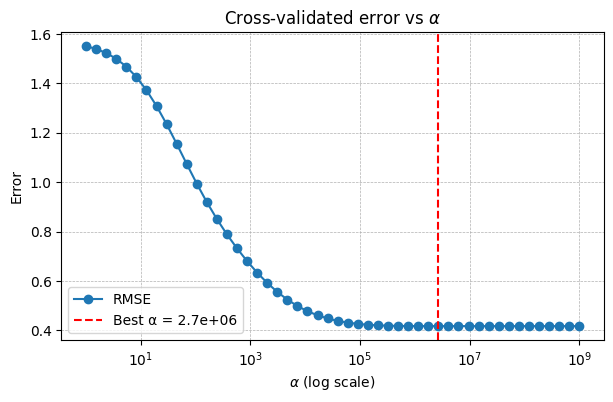


Best alpha = 2682695.7952797273


In [9]:
from sklearn.linear_model import RidgeCV
import numpy as np
import matplotlib.pyplot as plt

# lets test the ridge model with multiple values of alpha
alpha_grid = np.logspace(0, 9, 50)
print(f"Checking {len(alpha_grid)} values of alpha\n")

# train using leave-one-out CV (cv=None) — required to store per-alpha scores, and is fast due to SVD shortcut
model = RidgeCV(alphas=alpha_grid, cv=None, store_cv_results=True)
model.fit(X_train, y_train)

# average the cv scores across samples for each alpha, then take the root to get RMSE
# cv_results_ shape is (n_samples, n_targets, n_alphas) — average across both samples and targets
cv_rmse = np.sqrt(model.cv_results_.mean(axis=(0, 1)))


# make a plot to show the RMSE across all alpha values
plt.figure(figsize=(7, 4))
ax = plt.gca()
ax.ticklabel_format(style='plain', axis='y', useOffset=False)
plt.plot(alpha_grid, cv_rmse, marker='o', label="RMSE")
plt.axvline(model.alpha_, color='red', linestyle='--', label=f'Best α = {model.alpha_:.2g}')
plt.xscale('log')
plt.xlabel("$\\alpha$ (log scale)")
plt.ylabel("Error")
plt.title("Cross-validated error vs $\\alpha$")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.show()

best_alpha =  model.alpha_
print("\nBest alpha =", best_alpha)

In [10]:
from sklearn.linear_model import Ridge
# the model will use is the actual best alpha value that we saw from the test set
final_model = Ridge(alpha=best_alpha)
final_model.fit(X_train, y_train)

print("Final model trained")
print("Best alpha =", best_alpha)

Final model trained
Best alpha = 2682695.7952797273


In [11]:
# -----------------------------
# 5) DataLoader + Flattening for Validation Data
# -----------------------------

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    drop_last=False,
)

all_validation_feature_batches = []
all_validation_target_batches = []

MAX_VALIDATION_BATCHES = 200
# MAX_VALIDATION_BATCHES = None

for batch_index, batch_dict in enumerate(validation_loader):
    emg_batch = batch_dict['emg']
    joint_angle_batch = batch_dict['joint_angles']

    batch_size_value = emg_batch.shape[0]

    # Flatten EMG to 2D for scikit-learn compatibility
    emg_features_2d = emg_batch.reshape(batch_size_value, -1)

    # Match the same target definition used for training
    final_timestep_joint_angles = joint_angle_batch[:, :, -1]

    all_validation_feature_batches.append(emg_features_2d.cpu().numpy())
    all_validation_target_batches.append(final_timestep_joint_angles.cpu().numpy())

    if MAX_VALIDATION_BATCHES is not None:
        if batch_index + 1 >= MAX_VALIDATION_BATCHES:
            break

X_val = np.concatenate(all_validation_feature_batches, axis=0)
y_val = np.concatenate(all_validation_target_batches, axis=0)

print('X_val shape =', X_val.shape)
print('y_val shape =', y_val.shape)


Streaming output truncated to the last 5000 lines.


X_val shape = (6400, 32000)
y_val shape = (6400, 20)


In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
y_val_pred = final_model.predict(X_val)
mae = mean_absolute_error(y_val, y_val_pred)
mse = mean_squared_error(y_val, y_val_pred)
print('MAE =', mae)
print('MSE =', mse)

MAE = 0.3260866105556488
MSE = 0.1821724772453308
